#   Spam vs Ham Text Classification




In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup and Imports

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, time, warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1-4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow: {tf.__version__} | NumPy: {np.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0 | NumPy: 2.0.2
GPU: []


[nltk_data] Error loading omw-1-4: Package 'omw-1-4' not found in
[nltk_data]     index


## Load and Explore Dataset

In [35]:
df = pd.read_csv("/content/drive/MyDrive/AI   ML Final Assignment/9.Spam vs Ham Sms Dataset/spamvsham.csv", encoding='latin-1', header=0,
                 names=['label','text','c','d','e'], usecols=['label','text'])

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print(df.head())
print("\nLabel distribution:")
print(df['label'].value_counts())
print(f"Spam ratio: {df['label'].value_counts(normalize=True)['spam']*100:.1f}%")

Shape: (5572, 2)
Missing values: 0
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Label distribution:
label
ham     4825
spam     747
Name: count, dtype: int64
Spam ratio: 13.4%


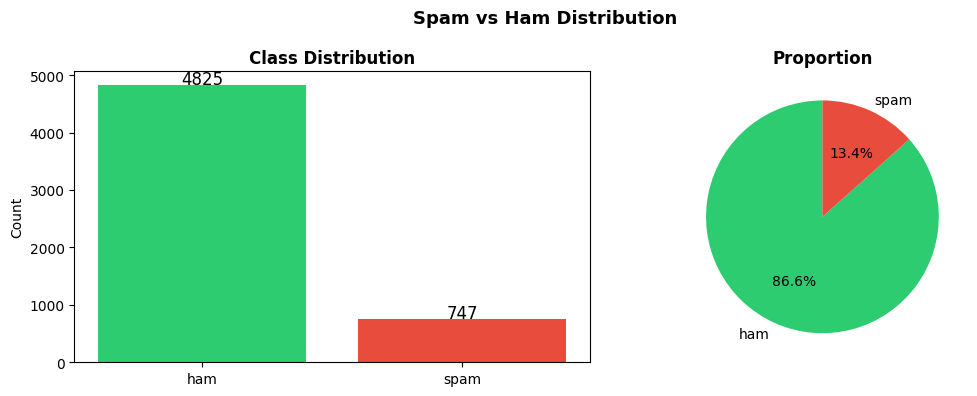

Observation: Dataset is IMBALANCED - 87% Ham, 13% Spam.
This means accuracy alone is misleading. We must check F1-score for spam class.


In [36]:
# Class distribution visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
counts = df['label'].value_counts()
ax1.bar(counts.index, counts.values, color=['#2ecc71','#e74c3c'])
ax1.set_title("Class Distribution", fontweight='bold')
ax1.set_ylabel("Count")
for i, (k, v) in enumerate(counts.items()):
    ax1.text(i, v+20, str(v), ha='center', fontsize=12)
ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=['#2ecc71','#e74c3c'], startangle=90)
ax2.set_title("Proportion", fontweight='bold')
plt.suptitle("Spam vs Ham Distribution", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig("label_distribution.png", dpi=150); plt.show()
print("Observation: Dataset is IMBALANCED - 87% Ham, 13% Spam.")
print("This means accuracy alone is misleading. We must check F1-score for spam class.")

Message length stats by class:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


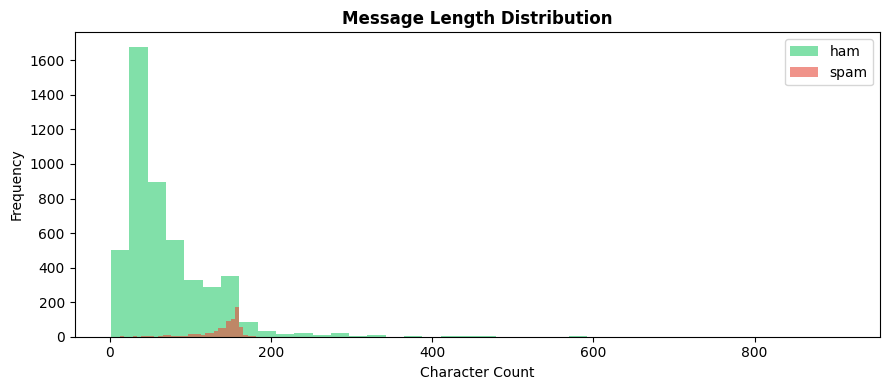

Observation: Spam messages tend to be longer (promotional language, links, offers).


In [37]:
# Text length analysis
df['text_len'] = df['text'].apply(len)
print("Message length stats by class:")
print(df.groupby('label')['text_len'].describe())
fig, ax = plt.subplots(figsize=(9, 4))
for label, color in [('ham','#2ecc71'),('spam','#e74c3c')]:
    ax.hist(df[df['label']==label]['text_len'], bins=40, alpha=0.6, label=label, color=color)
ax.set_title("Message Length Distribution", fontweight='bold')
ax.set_xlabel("Character Count"); ax.set_ylabel("Frequency"); ax.legend()
plt.tight_layout(); plt.show()
print("Observation: Spam messages tend to be longer (promotional language, links, offers).")

## 2. Text Preprocessing

In [38]:
# Contraction mapping
CONTRACTIONS = {
    "don't":"do not","does not":"does not","can't":"cannot","won't":"will not",
    "i'm":"i am","i've":"i have","it's":"it is","you're":"you are",
    "that's":"that is","didn't":"did not","isn't":"is not","wasn't":"was not",
    "we're":"we are","they're":"they are","i'll":"i will","you'll":"you will",
    "he's":"he is","she's":"she is","we've":"we have","they've":"they have"
}

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

print("Original: ", df['text'].iloc[2])
print("Cleaned:  ", df['clean_text'].iloc[2])
print()
print("Original: ", df['text'].iloc[3])
print("Cleaned:  ", df['clean_text'].iloc[3])

Original:  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned:   free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply over

Original:  U dun say so early hor... U c already then say...
Cleaned:   dun say early hor already say


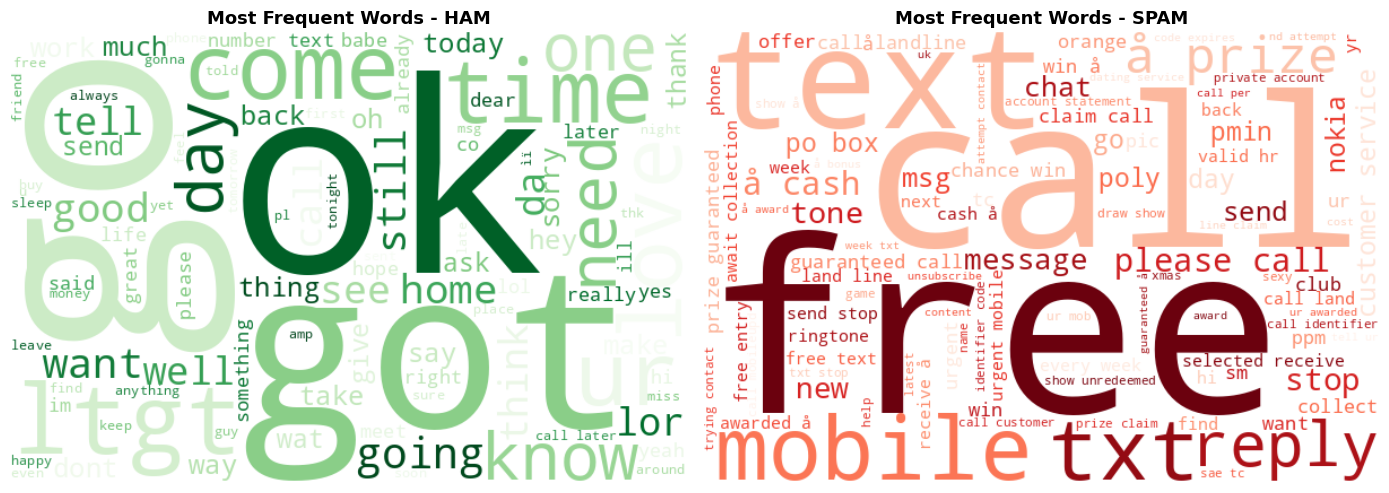

Top ham words: ['get', 'ltgt', 'go', 'ok', 'come', 'know', 'call', 'ur', 'got', 'like', 'good', 'day', 'time', 'love', 'want']
Top spam words: ['call', 'å£', 'free', 'txt', 'ur', 'text', 'mobile', 'stop', 'claim', 'reply', 'prize', 'get', 'tone', 'service', 'nokia']


In [39]:
# WordCloud visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, cmap in [(axes[0],'ham','Greens'),(axes[1],'spam','Reds')]:
    text = ' '.join(df[df['label']==label]['clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Most Frequent Words - {label.upper()}", fontsize=13, fontweight='bold')
    ax.axis('off')
plt.tight_layout(); plt.savefig("wordclouds.png", dpi=150); plt.show()

# Top 15 words per class
for label in ['ham', 'spam']:
    words = ' '.join(df[df['label']==label]['clean_text']).split()
    top15 = [w for w, _ in Counter(words).most_common(15)]
    print(f"Top {label} words: {top15}")

## 3. Tokenization and Sequence Padding

In [40]:
# Encode labels: ham=0, spam=1
df['label_num'] = (df['label'] == 'spam').astype(int)

# Train/test split - stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_num'],
    test_size=0.20, random_state=42, stratify=df['label_num']
)
print(f"Train: {len(X_train)} samples  |  Test: {len(X_test)} samples")
print(f"Train spam%: {y_train.mean()*100:.1f}%  |  Test spam%: {y_test.mean()*100:.1f}%")

Train: 4457 samples  |  Test: 1115 samples
Train spam%: 13.4%  |  Test spam%: 13.4%


In [41]:
# Tokenize
VOCAB_SIZE = 10000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)   # fit ONLY on train data!

train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs  = tokenizer.texts_to_sequences(X_test)
word_index = tokenizer.word_index

print(f"Unique words found: {len(word_index):,}")
print(f"Vocabulary used:    {VOCAB_SIZE:,} (top words)")
print(f"Sample sequence: {train_seqs[0]}")

Unique words found: 6,979
Vocabulary used:    10,000 (top words)
Sample sequence: [22, 219, 3137]


In [42]:
# Pad sequences using 90th percentile length
lengths = [len(s) for s in train_seqs]
MAX_LEN = int(np.percentile(lengths, 90))
print(f"90th percentile sequence length: {MAX_LEN} tokens -> using as MAX_LEN")
print(f"Mean: {np.mean(lengths):.1f}, Max: {max(lengths)}, Min: {min(lengths)}")

X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f"Train shape: {X_train_pad.shape}")
print(f"Test shape:  {X_test_pad.shape}")
print("Padding='post' adds zeros at the end. Truncating='post' cuts long sequences from end.")

90th percentile sequence length: 16 tokens -> using as MAX_LEN
Mean: 8.3, Max: 79, Min: 0
Train shape: (4457, 16)
Test shape:  (1115, 16)
Padding='post' adds zeros at the end. Truncating='post' cuts long sequences from end.


## 4. Model Building

In [43]:
import tensorflow.keras as keras

# Shared settings
EMBED_DIM  = 64
RNN_UNITS  = 64
LSTM_UNITS = 64
EPOCHS     = 30
BATCH_SIZE = 64

callbacks_list = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1)]

### Model 1: Simple RNN

SimpleRNN processes sequence left to right but suffers from vanishing gradient on long sequences.

In [52]:
import time
import tensorflow.keras as keras
import numpy as np

# Variables & Data Check
VOCAB_SIZE = 10000
MAX_LEN = 16
EMBED_DIM = 64
RNN_UNITS = 64
EPOCHS = 30
BATCH_SIZE = 64

try:
    X_train_data = X_train_pad
    y_train_data = y_train
except NameError:
    print('Error: Training data not found. Please run preprocessing.')
    X_train_data, y_train_data = None, None

callbacks_list = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1)]

#  Model 1: SimpleRNN
model1 = keras.Sequential([
    keras.layers.Input(shape=(MAX_LEN,)),
    keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, name='embedding'),
    keras.layers.SimpleRNN(RNN_UNITS, return_sequences=False, name='rnn'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid', name='output')
], name='SimpleRNN_Model')

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model1.summary()

if X_train_data is not None:
    t0 = time.time()
    history1 = model1.fit(
        X_train_data, y_train_data, epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.1, callbacks=callbacks_list, verbose=1
    )
    time1 = time.time() - t0
    print(f'SimpleRNN training time: {time1:.1f}s')

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 16, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,369 (2.48 MB)

 Trainable params: 650,369 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9227 - loss: 0.2214 - val_accuracy: 0.9439 - val_loss: 0.1592
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9865 - loss: 0.0610 - val_accuracy: 0.9664 - val_loss: 0.1137
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9948 - loss: 0.0239 - val_accuracy: 0.9709 - val_loss: 0.1063
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9960 - loss: 0.0181 - val_accuracy: 0.9686 - val_loss: 0.1400
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9975 - loss: 0.0104 - val_accuracy: 0.9686 - val_loss: 0.1596
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.9709 - val_loss: 0.1512
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9686 - val_loss: 0.2090
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9995 - loss: 0.0032 - val_accuracy: 0.9709 - v

### Model 2: LSTM

LSTM uses gates (forget, input, output) to selectively remember and forget information. Handles long-range dependencies much better than SimpleRNN.

In [53]:
# Model 2: LSTM
model2 = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, name='embedding'),
    layers.LSTM(LSTM_UNITS, return_sequences=True,  name='lstm1'),
    layers.Dropout(0.3),
    layers.LSTM(32, return_sequences=False, name='lstm2'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', name='output')
], name='LSTM_Model')

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

t0 = time.time()
history2 = model2.fit(
    X_train_pad, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1, callbacks=callbacks_list, verbose=1
)
time2 = time.time() - t0
print(f"LSTM training time: {time2:.1f}s")

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 16, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 16, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,529 (2.62 MB)

 Trainable params: 686,529 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9112 - loss: 0.2814 - val_accuracy: 0.9462 - val_loss: 0.1719
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9823 - loss: 0.0769 - val_accuracy: 0.9641 - val_loss: 0.1024
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9943 - loss: 0.0254 - val_accuracy: 0.9709 - val_loss: 0.1047
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9978 - loss: 0.0122 - val_accuracy: 0.9731 - val_loss: 0.1226
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9985 - loss: 0.0084 - val_accuracy: 0.9731 - val_loss: 0.1475
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9993 - loss: 0.0038 - val_accuracy: 0.9753 - val_loss: 0.1667
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9985 - loss: 0.0071 - val_accuracy: 0.9686 - val_loss: 0.1885
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.
LSTM training time: 18.6s


### Model 3: LSTM + Pretrained GloVe Embeddings

GloVe vectors encode semantic relationships learned from billions of words. The embedding layer starts already knowing that 'free' and 'win' are related, helping the model detect spam patterns faster.

In [46]:
import sys
if 'gensim' not in sys.modules:
  %pip install gensim --quiet

import gensim.downloader as api
print("Downloading GloVe-50 (~66MB)...")
glove_model = api.load('glove-wiki-gigaword-50')
EMBED_W2V = 50

# Build embedding matrix from GloVe
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_W2V))
found, not_found = 0, 0
for word, idx in word_index.items():
    if idx < VOCAB_SIZE:
        if word in glove_model:
            embedding_matrix[idx] = glove_model[word]
            found += 1
        else:
            not_found += 1
print(f"Found in GloVe: {found:,} | Not found: {not_found:,}")
print(f"Coverage: {found/(found+not_found)*100:.1f}%")

Found in GloVe: 5,059 | Not found: 1,920
Coverage: 72.5%


In [54]:
#  Model 3: LSTM + GloVe
model3 = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_W2V,
                     weights=[embedding_matrix], trainable=False, name='glove_embedding'),
    layers.LSTM(LSTM_UNITS, return_sequences=True,  name='lstm1'),
    layers.Dropout(0.3),
    layers.LSTM(32, return_sequences=False, name='lstm2'),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid', name='output')
], name='LSTM_GloVe_Model')

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

t0 = time.time()
history3 = model3.fit(
    X_train_pad, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1, callbacks=callbacks_list, verbose=1
)
time3 = time.time() - t0
print(f"LSTM+GloVe training time: {time3:.1f}s")

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ (None, 16, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 16, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,945 (2.07 MB)

 Trainable params: 42,945 (167.75 KB)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9010 - loss: 0.3199 - val_accuracy: 0.9170 - val_loss: 0.1992
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9554 - loss: 0.1418 - val_accuracy: 0.9484 - val_loss: 0.1602
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9641 - loss: 0.1165 - val_accuracy: 0.9439 - val_loss: 0.1517
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9653 - loss: 0.0985 - val_accuracy: 0.9619 - val_loss: 0.1193
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9723 - loss: 0.0835 - val_accuracy: 0.9574 - val_loss: 0.1121
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.
LSTM+GloVe training time: 14.1s


## 5. Evaluation and Comparison

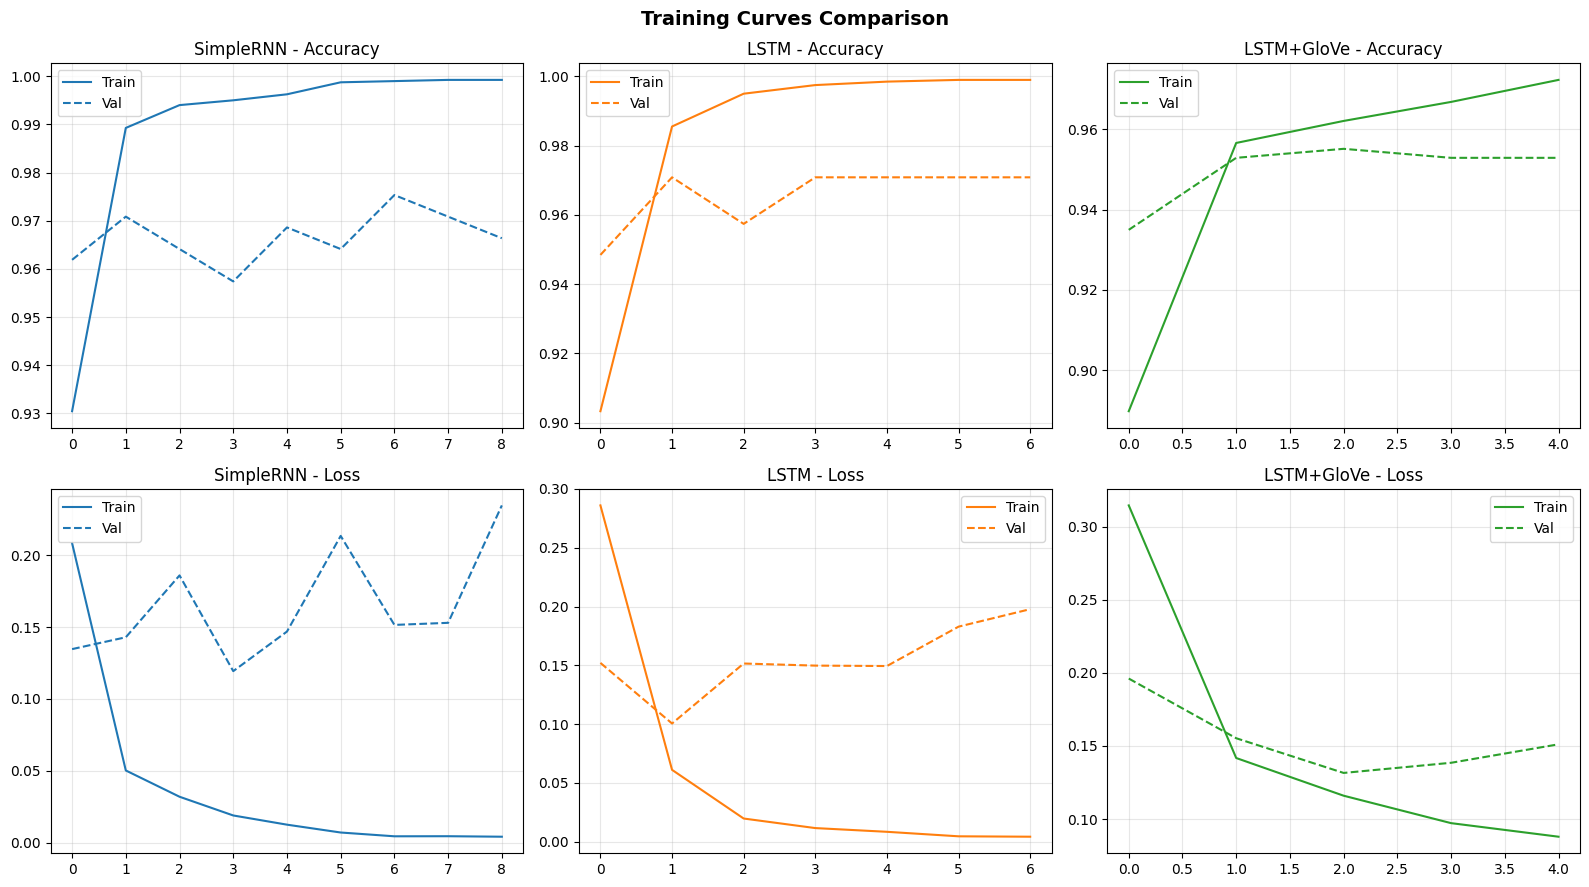

In [48]:
# Training curves for all 3 models
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
info = [(history1,"SimpleRNN",'#1f77b4'),
        (history2,"LSTM",'#ff7f0e'),
        (history3,"LSTM+GloVe",'#2ca02c')]
for col, (h, name, color) in enumerate(info):
    axes[0,col].plot(h.history['accuracy'], label='Train', color=color)
    axes[0,col].plot(h.history['val_accuracy'], label='Val', color=color, linestyle='--')
    axes[0,col].set_title(f"{name} - Accuracy"); axes[0,col].legend(); axes[0,col].grid(alpha=0.3)
    axes[1,col].plot(h.history['loss'], label='Train', color=color)
    axes[1,col].plot(h.history['val_loss'], label='Val', color=color, linestyle='--')
    axes[1,col].set_title(f"{name} - Loss"); axes[1,col].legend(); axes[1,col].grid(alpha=0.3)
plt.suptitle("Training Curves Comparison", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig("training_curves.png", dpi=150); plt.show()


 SimpleRNN
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.97      0.81      0.88       149

    accuracy                           0.97      1115
   macro avg       0.97      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



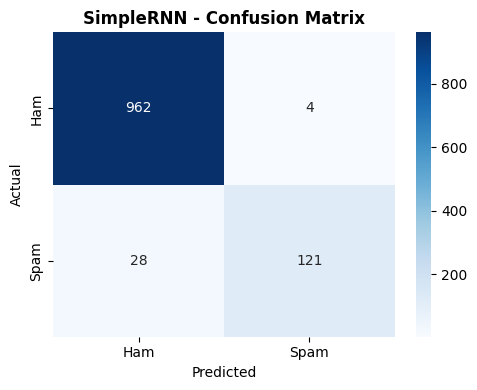


 LSTM
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       966
        Spam       0.95      0.79      0.86       149

    accuracy                           0.97      1115
   macro avg       0.96      0.89      0.92      1115
weighted avg       0.97      0.97      0.96      1115



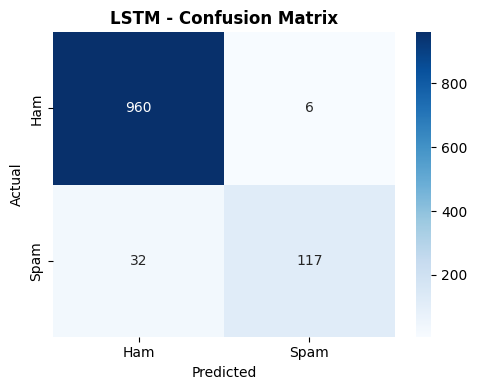


 LSTM GloVe
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       966
        Spam       0.91      0.90      0.90       149

    accuracy                           0.97      1115
   macro avg       0.94      0.94      0.94      1115
weighted avg       0.97      0.97      0.97      1115



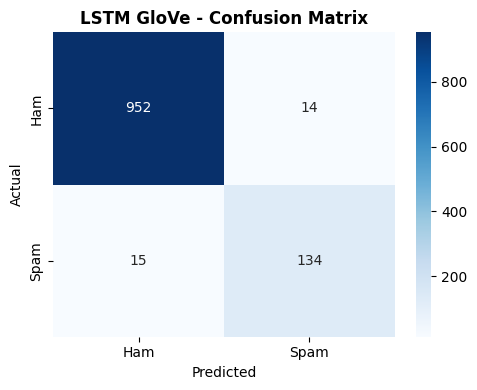

In [28]:
# Evaluate all models
def eval_nlp(model, X, y, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n{'='*50}\n {name}\n{'='*50}")
    print(classification_report(y, y_pred, target_names=['Ham','Spam']))
    cm = confusion_matrix(y, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'], ax=ax)
    ax.set_title(f"{name} - Confusion Matrix", fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout(); plt.savefig(f"cm_{name.replace(' ','_')}.png", dpi=150); plt.show()
    return accuracy_score(y, y_pred), f1_score(y, y_pred)

acc1, f1_1 = eval_nlp(model1, X_test_pad, y_test, "SimpleRNN")
acc2, f1_2 = eval_nlp(model2, X_test_pad, y_test, "LSTM")
acc3, f1_3 = eval_nlp(model3, X_test_pad, y_test, "LSTM GloVe")

       Model  Accuracy (%)  F1-Score  Train Time(s)
   SimpleRNN         97.13    0.8832           10.8
        LSTM         96.59    0.8603           15.1
LSTM + GloVe         97.40    0.9024           26.8


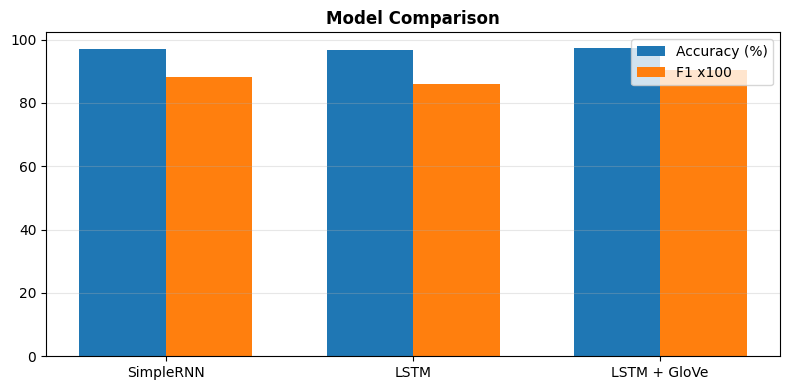

In [29]:
# Summary table
summary = pd.DataFrame({
    'Model':         ['SimpleRNN', 'LSTM', 'LSTM + GloVe'],
    'Accuracy (%)':  [round(acc1*100,2), round(acc2*100,2), round(acc3*100,2)],
    'F1-Score':      [round(f1_1,4), round(f1_2,4), round(f1_3,4)],
    'Train Time(s)': [round(time1,1), round(time2,1), round(time3,1)]
})
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3); width = 0.35
ax.bar(x-width/2, summary['Accuracy (%)'], width, label='Accuracy (%)', color='#1f77b4')
ax.bar(x+width/2, summary['F1-Score']*100, width, label='F1 x100', color='#ff7f0e')
ax.set_xticks(x); ax.set_xticklabels(summary['Model'])
ax.set_title("Model Comparison", fontweight='bold'); ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig("nlp_comparison.png", dpi=150); plt.show()

## 6. Error Analysis

In [30]:
# Misclassified examples using LSTM (Model 2)
y_prob2 = model2.predict(X_test_pad, verbose=0).flatten()
y_pred2 = (y_prob2 >= 0.5).astype(int)

X_test_list = list(X_test)
y_true_list = list(y_test)
orig_texts = df.loc[X_test.index, 'text'].tolist()

errors = [(orig_texts[i], X_test_list[i], y_true_list[i], y_pred2[i], y_prob2[i])
          for i in range(len(y_true_list)) if y_true_list[i] != y_pred2[i]]

label_map = {0:'Ham', 1:'Spam'}
print(f"Total misclassified: {len(errors)} / {len(y_true_list)}")

# False Positives (Ham wrongly classified as Spam)
fp = [(o, c, t, p, pr) for o, c, t, p, pr in errors if t == 0]
fn = [(o, c, t, p, pr) for o, c, t, p, pr in errors if t == 1]
print(f"False Positives (Ham -> Spam): {len(fp)}")
print(f"False Negatives (Spam -> Ham): {len(fn)}")

print("\n--- 3 False Positives (innocent messages flagged as spam) ---")
for o, c, t, p, pr in fp[:3]:
    print(f"  Msg: '{o[:80]}'")
    print(f"  Confidence: {pr:.2f}\n")

print("--- 3 False Negatives (spam that slipped through) ---")
for o, c, t, p, pr in fn[:3]:
    print(f"  Msg: '{o[:80]}'")
    print(f"  Confidence: {pr:.2f}\n")

Total misclassified: 38 / 1115
False Positives (Ham -> Spam): 6
False Negatives (Spam -> Ham): 32

--- 3 False Positives (innocent messages flagged as spam) ---
  Msg: 'New Theory: Argument wins d SITUATION, but loses the PERSON. So dont argue with '
  Confidence: 0.60

  Msg: 'It will stop on itself. I however suggest she stays with someone that will be ab'
  Confidence: 0.54

  Msg: 'Call to the number which is available in appointment. And ask to connect the cal'
  Confidence: 0.83

--- 3 False Negatives (spam that slipped through) ---
  Msg: 'You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327'
  Confidence: 0.16

  Msg: 'FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some'
  Confidence: 0.10

  Msg: 'Talk sexy!! Make new friends or fall in love in the worlds most discreet text da'
  Confidence: 0.09



In [31]:
# Model complexity vs performance
print("=== Model Complexity vs Performance ===")
print(f"SimpleRNN: {model1.count_params():,} params | Acc: {acc1*100:.2f}% | F1: {f1_1:.4f}")
print(f"LSTM:      {model2.count_params():,} params | Acc: {acc2*100:.2f}% | F1: {f1_2:.4f}")
print(f"LSTM+GloVe:{model3.count_params():,} params | Acc: {acc3*100:.2f}% | F1: {f1_3:.4f}")
print()
print("Possible reasons for errors:")
print("1. False Positives: Messages with spam-like words (free, win, prize) but sent by")
print("   friends. Context and sender identity cannot be captured by word-level models.")
print("2. False Negatives: Sophisticated spam that avoids common spam keywords,")
print("   uses abbreviations (ur, txt, gr8) not well represented in GloVe vocabulary.")
print("3. Imbalanced data: Model trained on 87% ham - biased toward predicting ham.")
print()
print("Suggested improvements:")
print("- Use class_weight to penalize errors on spam more heavily")
print("- Oversample spam using SMOTE on text features")
print("- Try Bidirectional LSTM for better context understanding")
print("- Add character-level features to handle SMS abbreviations")

=== Model Complexity vs Performance ===
SimpleRNN: 650,369 params | Acc: 97.13% | F1: 0.8832
LSTM:      686,529 params | Acc: 96.59% | F1: 0.8603
LSTM+GloVe:542,945 params | Acc: 97.40% | F1: 0.9024

Possible reasons for errors:
1. False Positives: Messages with spam-like words (free, win, prize) but sent by
   friends. Context and sender identity cannot be captured by word-level models.
2. False Negatives: Sophisticated spam that avoids common spam keywords,
   uses abbreviations (ur, txt, gr8) not well represented in GloVe vocabulary.
3. Imbalanced data: Model trained on 87% ham - biased toward predicting ham.

Suggested improvements:
- Use class_weight to penalize errors on spam more heavily
- Oversample spam using SMOTE on text features
- Try Bidirectional LSTM for better context understanding
- Add character-level features to handle SMS abbreviations


## 7. Real-Time Prediction GUI with Gradio

In [32]:
import gradio as gr

def predict_sms(message, model_choice):
    models_map = {"SimpleRNN": model1, "LSTM": model2, "LSTM + GloVe": model3}
    chosen = models_map[model_choice]
    cleaned = clean_text(message)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = chosen.predict(padded, verbose=0)[0][0]
    label = "SPAM" if prob >= 0.5 else "HAM (Not Spam)"
    confidence = max(prob, 1-prob) * 100
    return (f"Prediction: {label}\n"
            f"Confidence: {confidence:.1f}%\n"
            f"Cleaned text: {cleaned[:100]}")

demo = gr.Interface(
    fn=predict_sms,
    inputs=[
        gr.Textbox(label="Enter SMS Message",
                   placeholder="Type any SMS message here..."),
        gr.Dropdown(["SimpleRNN","LSTM","LSTM + GloVe"],
                    label="Choose Model", value="LSTM")
    ],
    outputs=gr.Textbox(label="Result"),
    title="SMS Spam Detector",
    description="Enter a message to classify it as Spam or Ham using trained models.",
    examples=[
        ["Congratulations! You have won a FREE iPhone. Click: bit.ly/win", "LSTM"],
        ["Hey are you coming to the meeting tomorrow?", "LSTM"],
        ["FREE entry to win FA Cup final tickets text FA to 87121", "LSTM + GloVe"]
    ]
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://53e8d1f0c16d756fe0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
